## 机器学习(ML) - 随机森林(RF)与XGBoost
利用10个最重要的物理化学描述符，采用传统ML算法实现溶解度预测

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split
from xgboost import plot_importance
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
compound_with_desc = pd.read_csv('data/comound_with_desc.csv')
descriptor = pd.read_csv('data/descriptor.csv')
descriptor.head(13)

,Unnamed: 0,descriptor,linear_abs_pearson,linear_pearson,nonlinear_mutual_info
0,0,MolLogP,0.827918,-0.827918,0.792878
1,1,PEOE_VSA6,0.704852,-0.704852,0.433297
2,2,MolMR,0.699756,-0.699756,0.500652
3,3,LabuteASA,0.655502,-0.655502,0.469273
4,4,Chi0v,0.654884,-0.654884,0.520071
5,5,MolWt,0.640189,-0.640189,0.467775
6,6,HeavyAtomMolWt,0.639511,-0.639511,0.500044
7,7,ExactMolWt,0.639112,-0.639112,0.458112
8,8,Chi1v,0.635888,-0.635888,0.541120
9,9,FpDensityMorgan1,0.600940,0.600940,0.249728


In [3]:
x_data = compound_with_desc[['MolLogP', 'PEOE_VSA6', 'MolMR', 'LabuteASA', 'Chi0v', 'MolWt', 'Chi1v', 'FpDensityMorgan1', 'BCUT2D_LOGPHI', 'BertzCT']]
#x_data = x_data.to_numpy()
x_data

,MolLogP,PEOE_VSA6,MolMR,LabuteASA,Chi0v,MolWt,Chi1v,FpDensityMorgan1,BCUT2D_LOGPHI,BertzCT
0,-3.10802,30.331835,102.2816,182.935327,16.862520,457.432,9.998816,0.812500,2.284935,724.155248
1,2.84032,18.199101,57.8402,87.724095,8.357948,201.225,4.676643,1.200000,2.120187,445.900366
2,2.87800,17.222229,48.4860,68.806046,7.554513,152.237,3.908188,1.272727,2.045141,166.477332
3,6.29940,84.929139,96.4660,128.158061,12.082904,278.354,7.636751,0.272727,2.338406,1071.547817
4,1.74810,12.132734,24.3190,35.071766,3.534146,84.143,2.414214,1.000000,1.910909,56.515178
...,...,...,...,...,...,...,...,...,...,...
1123,2.50850,15.929944,24.6230,51.771613,5.309098,197.381,2.644169,1.428571,2.280558,45.548875
1124,0.10710,5.155713,55.1847,86.647660,9.343917,219.266,4.973705,1.428571,2.014912,228.422865
1125,2.99000,18.305462,63.7600,88.079115,10.953692,246.359,9.003460,1.250000,2.591031,124.973737
1126,2.05240,27.192033,25.1290,34.199019,4.284457,72.151,2.270056,1.400000,1.933985,14.000000


In [4]:
y_data = compound_with_desc['measured log solubility in mols per litre']
y_data = y_data.to_numpy()
y_data

array([-0.77 , -3.3  , -2.06 , ..., -3.091, -3.18 , -4.522], shape=(1128,))

In [5]:
"""
RandomForest
"""
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=42)


rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=4,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_test = rf.predict(x_test)

y_pred_train = rf.predict(x_train)

print("R2(test):", r2_score(y_test, y_pred_test))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("rmse(test)",rmse_test)

print("R2(train):",r2_score(y_train, y_pred_train))
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print("rmse(train)",rmse_train)

R2(test): 0.8450377281903974
rmse(test) 0.840704888019045
R2(train): 0.8811398387166627
rmse(train) 0.7154691443306778


In [6]:
importances = rf.feature_importances_

feature_names = ['MolLogP', 'PEOE_VSA6', 'MolMR', 'LabuteASA', 'Chi0v', 'MolWt', 'Chi1v', 'FpDensityMorgan1', 'BCUT2D_LOGPHI', 'BertzCT']

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(importance_df)

            feature  importance
0           MolLogP    0.862963
9           BertzCT    0.037215
2             MolMR    0.032851
6             Chi1v    0.027863
7  FpDensityMorgan1    0.018086
5             MolWt    0.006599
3         LabuteASA    0.006512
8     BCUT2D_LOGPHI    0.003596
1         PEOE_VSA6    0.003224
4             Chi0v    0.001091


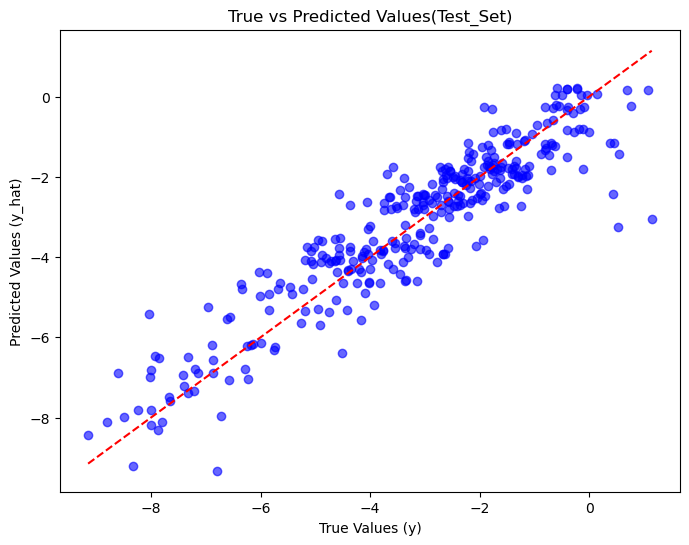

In [7]:
import matplotlib.pyplot as plt

# 画真实值 vs 预测值散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color='blue', alpha=0.6)

# 添加对角线（完美预测的线）
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

# 设置标题和标签
plt.title('True vs Predicted Values(Test_Set)')
plt.xlabel('True Values (y)')
plt.ylabel('Predicted Values (y_hat)')

# 显示图像
plt.show()

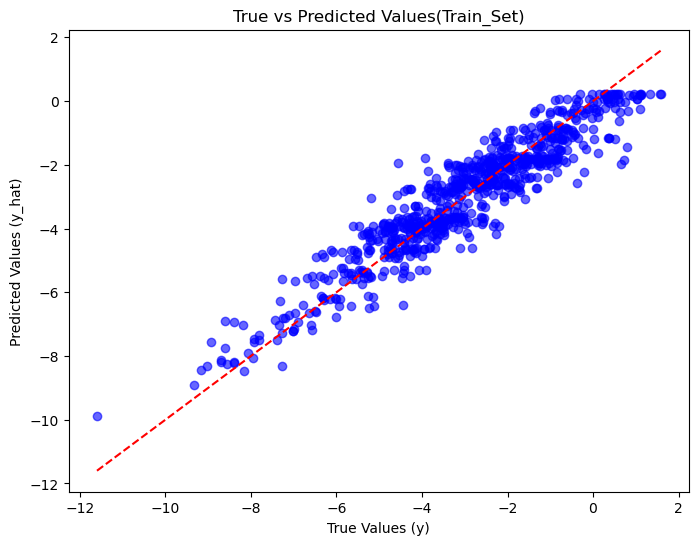

In [8]:
# 画真实值 vs 预测值散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred_train, color='blue', alpha=0.6)

# 添加对角线（完美预测的线）
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--')

# 设置标题和标签
plt.title('True vs Predicted Values(Train_Set)')
plt.xlabel('True Values (y)')
plt.ylabel('Predicted Values (y_hat)')

# 显示图像
plt.show()

In [9]:
"""
XGBoost
"""

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,         
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,        
    random_state=42
)


xgb_model.fit(x_train, y_train)

# 3. 预测与评估
y_pred_test = xgb_model.predict(x_test)
y_pred_train = xgb_model.predict(x_train)

print("--- XGBoost Results ---")
print(f"R2 (test): {r2_score(y_test, y_pred_test):.4f}")
print(f"RMSE (test): {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"R2 (train): {r2_score(y_train, y_pred_train):.4f}")
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print("rmse(train)",rmse_train)

--- XGBoost Results ---
R2 (test): 0.8581
RMSE (test): 0.8046
R2 (train): 0.8961
rmse(train) 0.6689898509943792


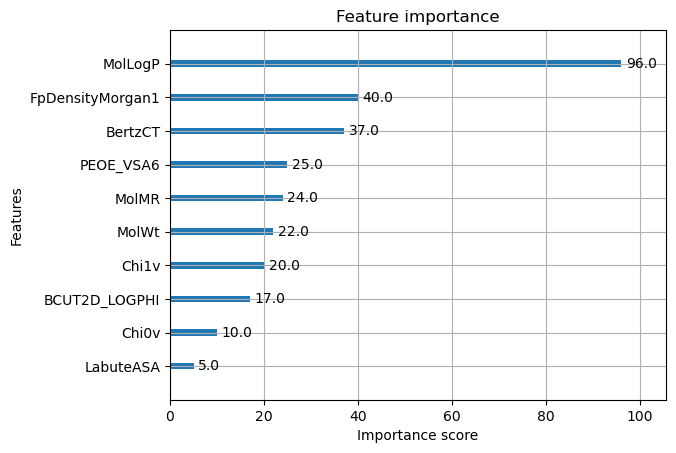

            feature       gain
0           MolLogP  85.994781
6             Chi1v  68.886673
2             MolMR  52.143616
1         PEOE_VSA6  37.580692
9           BertzCT  17.301315
4             Chi0v   8.678984
7  FpDensityMorgan1   8.633593
5             MolWt   6.387425
8     BCUT2D_LOGPHI   5.863409
3         LabuteASA   3.913515


In [10]:

plot_importance(xgb_model)
plt.show()


importance_gain = xgb_model.get_booster().get_score(importance_type='gain')


import pandas as pd
importance_df = pd.DataFrame({
    'feature': list(importance_gain.keys()),
    'gain': list(importance_gain.values())
}).sort_values(by='gain', ascending=False)

print(importance_df)

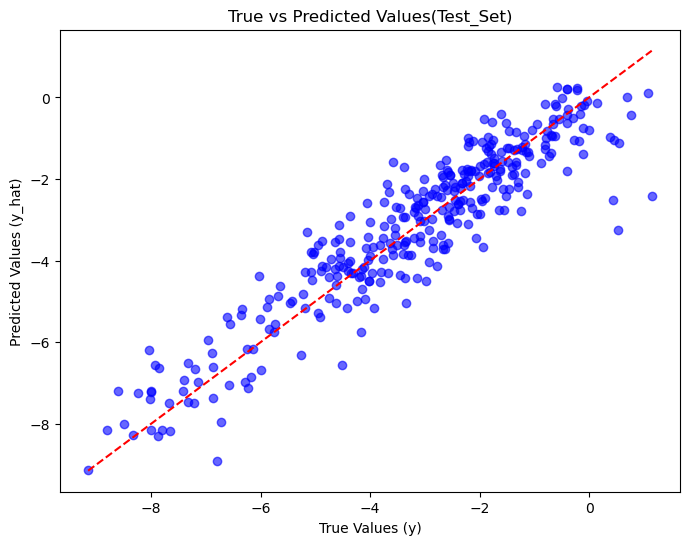

In [11]:
# 画真实值 vs 预测值散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color='blue', alpha=0.6)

# 添加对角线（完美预测的线）
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

# 设置标题和标签
plt.title('True vs Predicted Values(Test_Set)')
plt.xlabel('True Values (y)')
plt.ylabel('Predicted Values (y_hat)')

# 显示图像
plt.show()

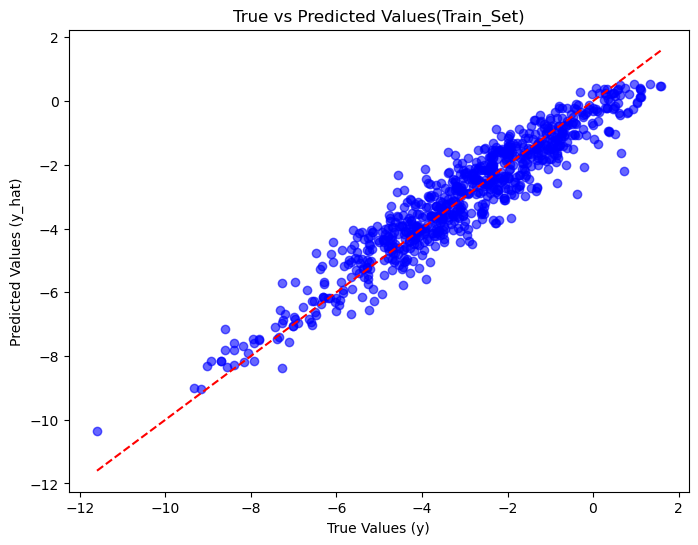

In [12]:
# 画真实值 vs 预测值散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred_train, color='blue', alpha=0.6)

# 添加对角线（完美预测的线）
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--')

# 设置标题和标签
plt.title('True vs Predicted Values(Train_Set)')
plt.xlabel('True Values (y)')
plt.ylabel('Predicted Values (y_hat)')

# 显示图像
plt.show()